In [1]:
import pandas as pd
import numpy as np

In [2]:
df_train = pd.read_csv("data-00-raw/bike_train.csv", index_col=[0], parse_dates=["date"])

df_train

,date,wcond,temp,atemp,hum,wind,count
1,2022-01-01,2,9.1,13.2,79.78,10.43,982
2,2022-01-02,2,9.9,12.7,68.91,16.16,797
3,2022-01-03,1,3.1,4.5,43.29,16.14,1351
4,2022-01-04,1,3.2,5.6,58.45,10.42,1559
5,2022-01-05,1,4.3,6.5,43.26,12.15,1597
...,...,...,...,...,...,...,...
361,2022-12-27,2,8.3,11.4,75.49,12.25,1161
362,2022-12-28,1,7.3,9.0,49.89,19.11,2301
363,2022-12-29,1,5.2,8.2,56.84,7.76,2421
364,2022-12-30,1,7.8,10.9,63.03,8.73,2995


In [34]:
df_test = pd.read_csv("data-00-raw/bike_test.csv", index_col=[0], parse_dates=["date"])

df_test

,date,wcond,temp,atemp,hum,wind
1,2023-01-01,1,10.2,13.8,68.56,12.49
2,2023-01-02,1,6.2,7.6,37.75,21.43
3,2023-01-03,1,1.1,1.3,43.68,23.77
4,2023-01-04,2,-0.6,1.0,41.04,12.01
5,2023-01-05,1,5.9,8.9,51.89,8.45
...,...,...,...,...,...,...
361,2023-12-27,3,5.0,6.0,81.51,20.58
362,2023-12-28,2,5.4,6.3,64.64,22.76
363,2023-12-29,2,5.4,7.8,58.41,10.11
364,2023-12-30,2,5.4,7.1,74.54,8.08


# Plotting

In [5]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

In [29]:
def configure_axis(ax: Axes) -> None:
    ax.grid(True, ls="--")

def plot_time_scatter(
        ax: Axes, 
        df: pd.DataFrame,
        plotted_y_col: str,
        date_col: str = "date",
    ) -> None:

    ax.scatter(df[date_col], df[plotted_y_col], s=5, marker=".", label = plotted_y_col)

    ax.legend()

    ax.set_title(plotted_y_col)

    # ax.set_xlabel("date")
    ax.set_ylabel(plotted_y_col)

In [38]:
def plot_selected_df(df_train: pd.DataFrame, df_test) -> None:
    fig, axs = plt.subplots(len(df_train.drop(columns=["date"]).columns), figsize=(12, 12), sharex=True)

    fig.tight_layout()

    for ax, col in zip(axs, df_train.drop(columns=["date"]).columns):
        configure_axis(ax)
        plot_time_scatter(ax, df_train, col, "date")

        configure_axis(ax)
        plot_time_scatter(ax, df_test, col, "date")

# Adding submission count

In [52]:
df_submission = pd.read_csv(f"outputs-submissions/submissions/2026-06-04___19:00:38___39.csv", parse_dates=["date"])

In [53]:
df_test["count"] = df_submission["pred"]

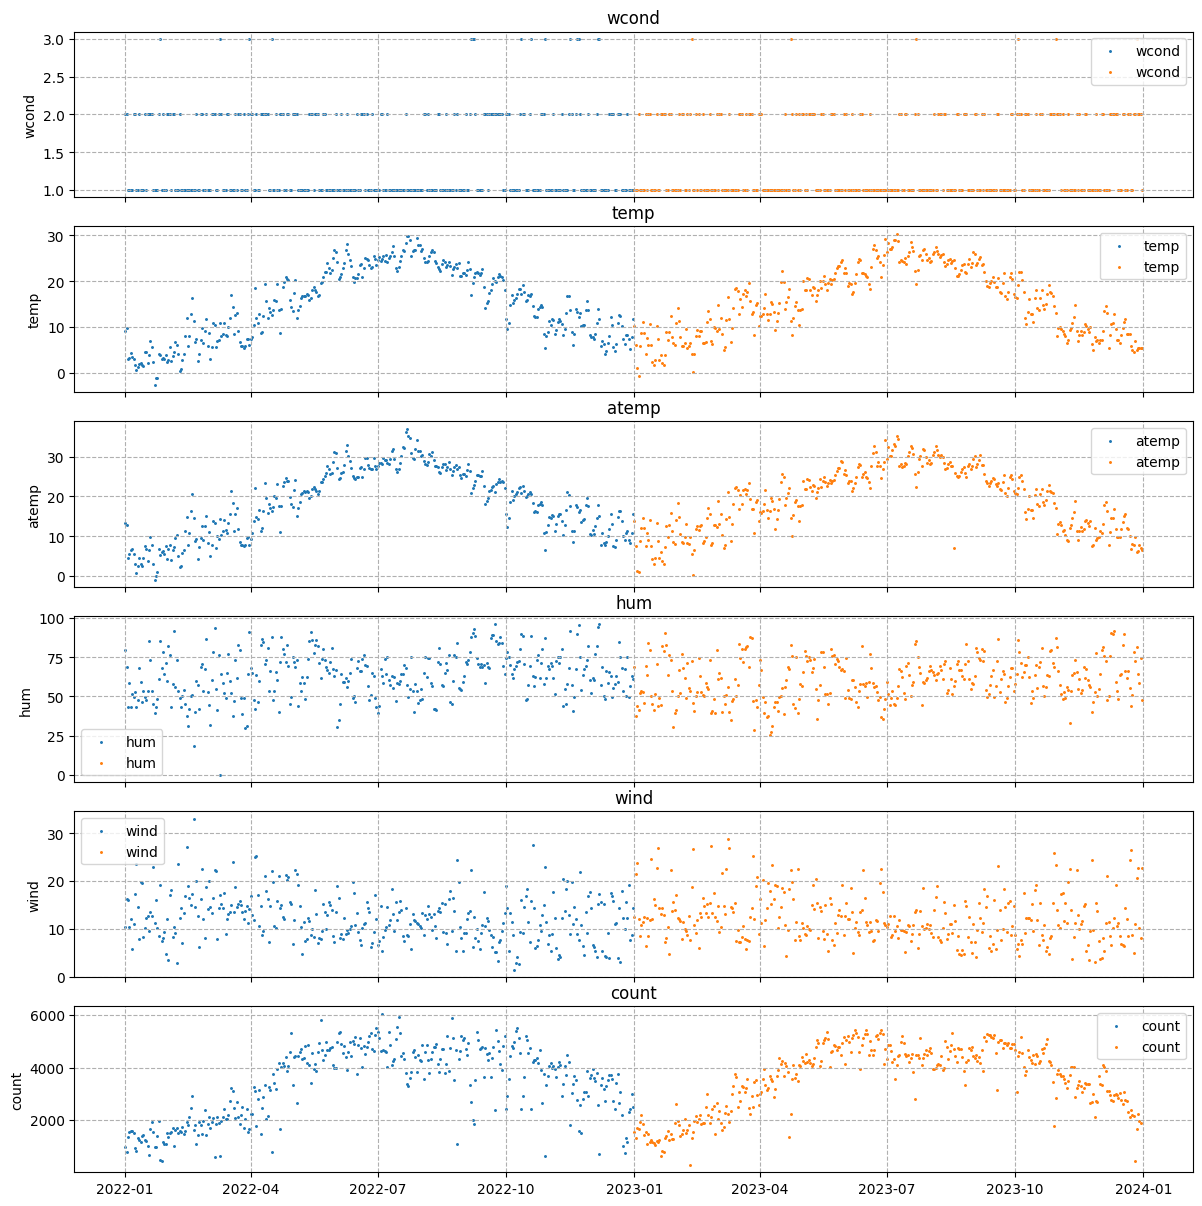

In [54]:
plot_selected_df(df_train, df_test)

# Plotting Section

In [9]:
from scripts.cluster_plotting import plot_all_columns, plot_hist

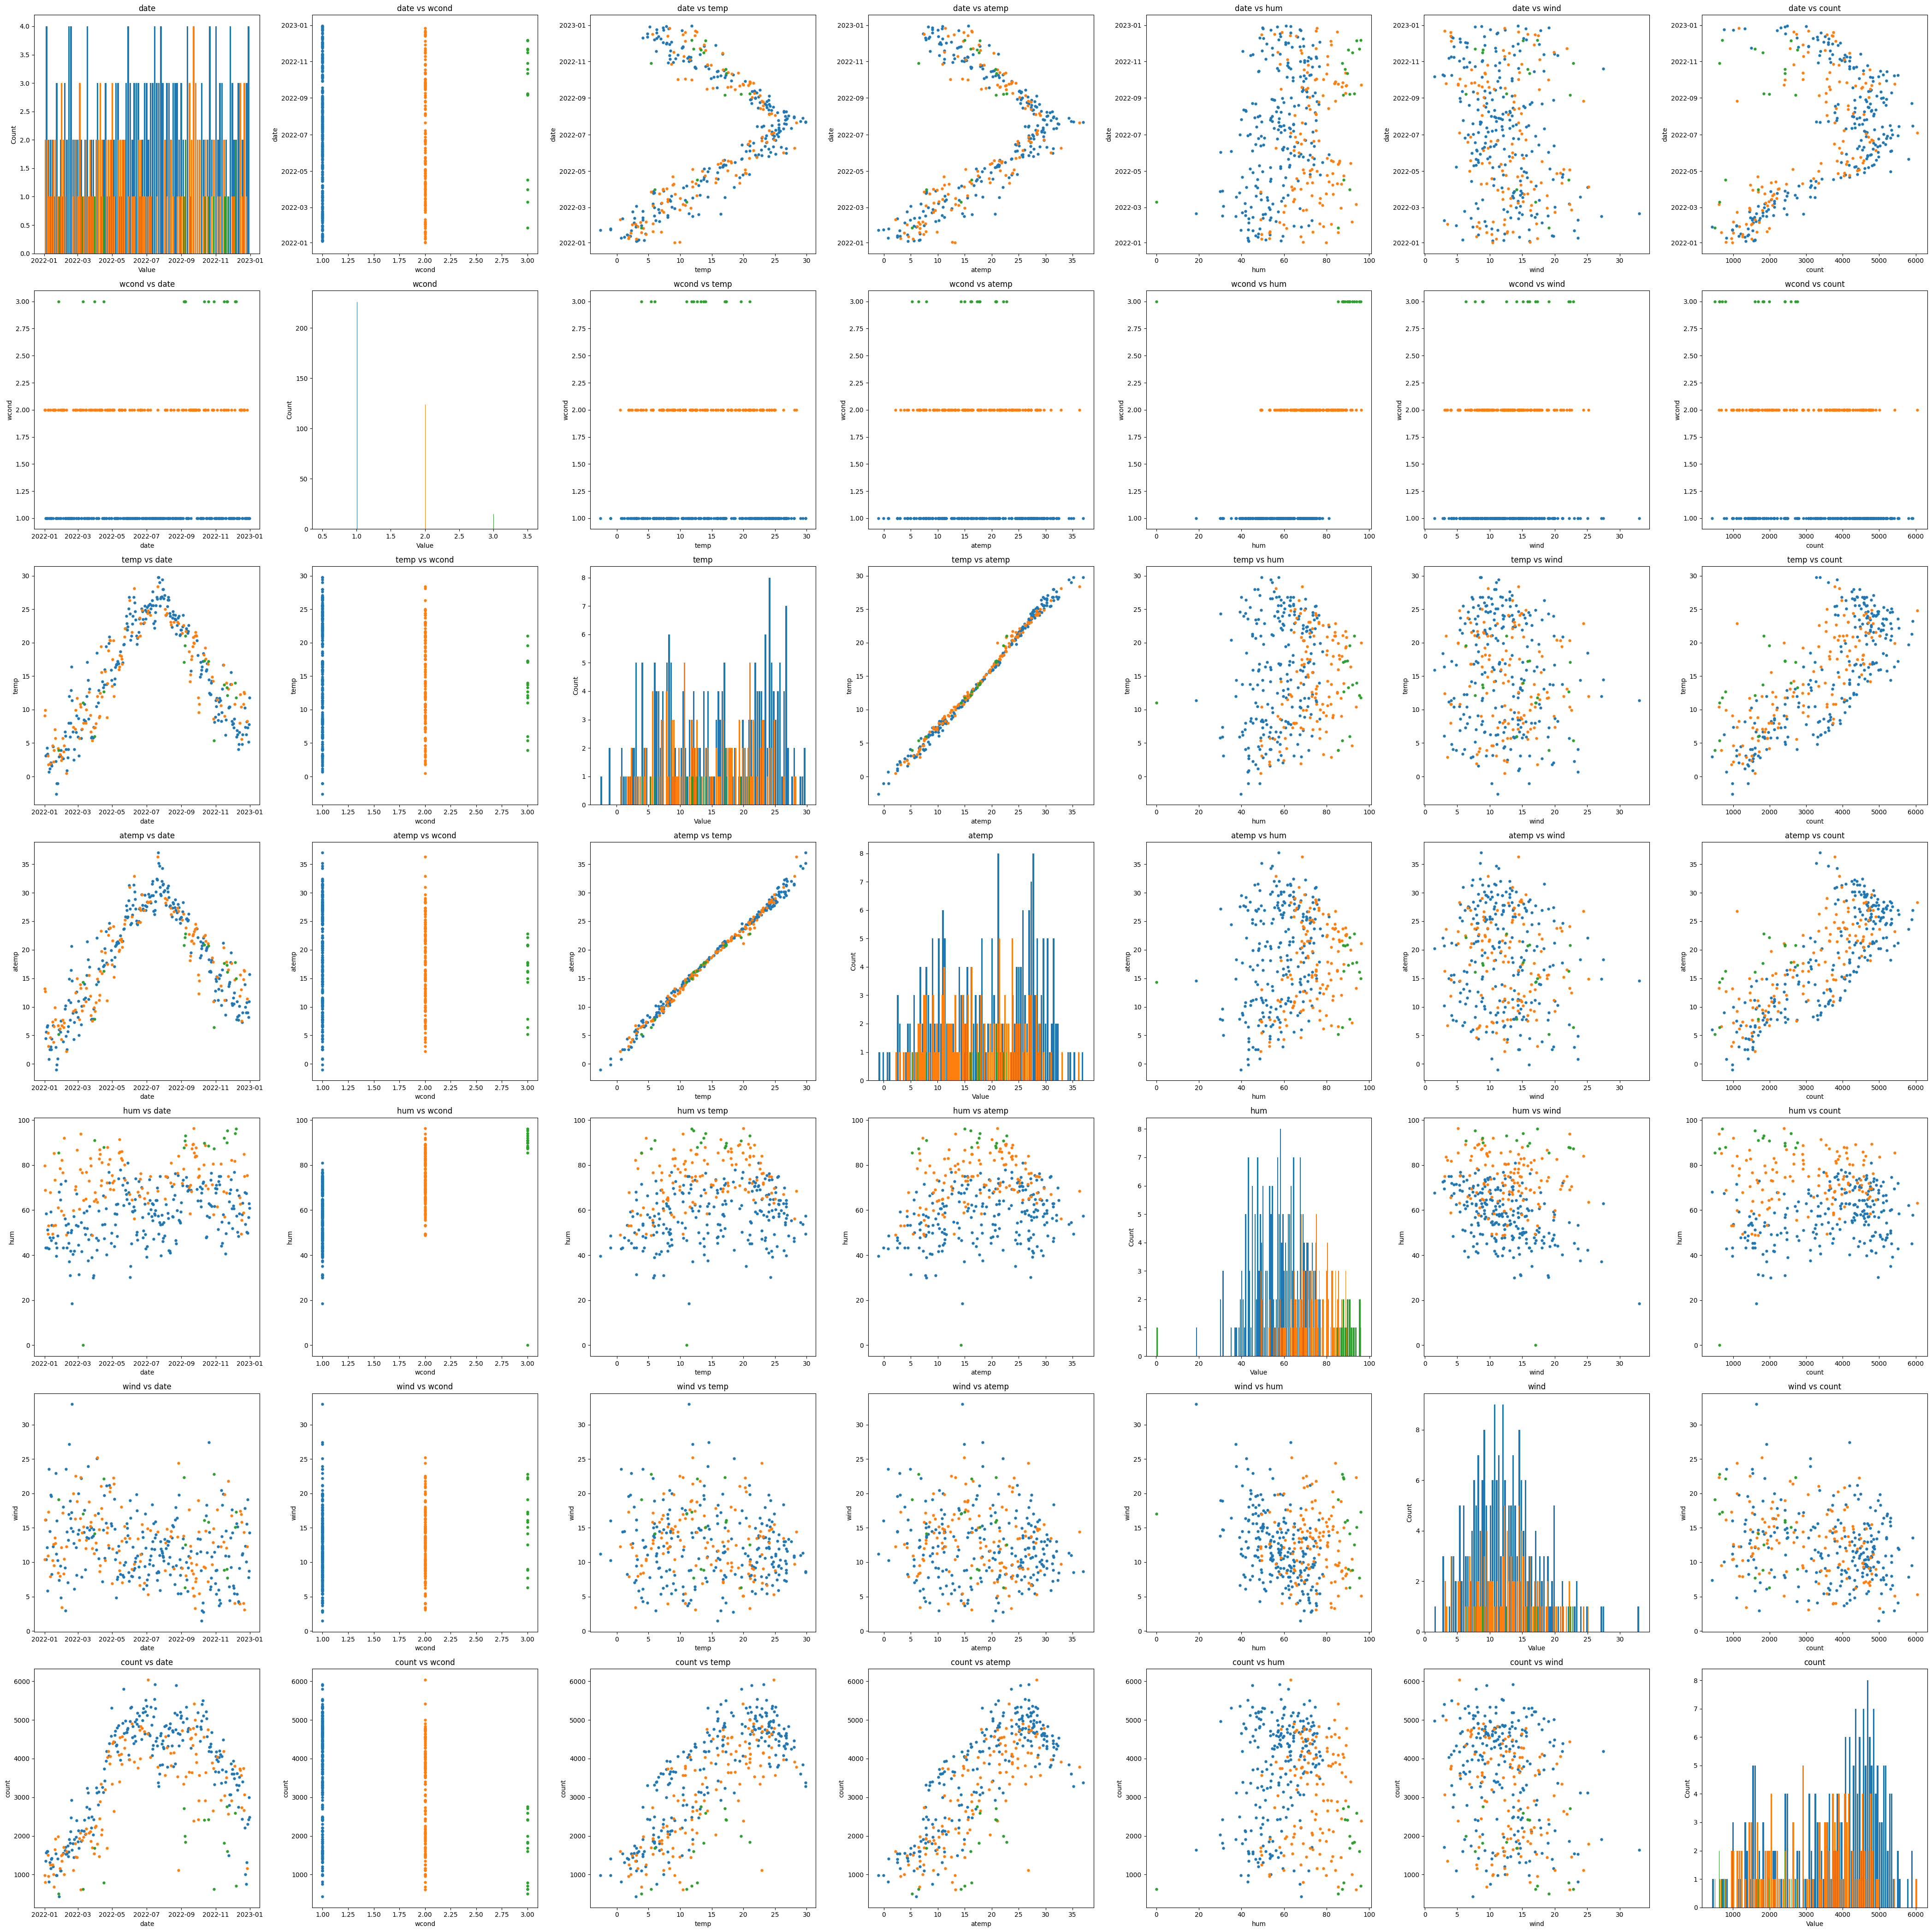

In [10]:
plot_all_columns(
    df_train,
    all_labels=df_train["wcond"],
    sel_labels=sorted([lab for lab in df_train["wcond"].unique()]),
    alpha = 1,
    point_size=50,
    bins_n=100
    )